# keras-hexagdly 2D example

This notebook mirrors HexagDLy's own `hexagdly_2d_example.ipynb`, ported to this Keras 3 package: same toy hexagonal data, same `Conv2d`/`debug=True` demonstration that a hex kernel conserves the symmetry of the hexagonal grid where a square kernel would not. It then adds two sections for the functionalities that are new in this port and have no HexagDLy equivalent: `share_neighbors` and `Conv3d(depth_padding="same")`.

Tensors here are channels-last: `(N, H, W, C)` for `Conv2d`/`MaxPool2d`, `(N, D, H, W, C)` for `Conv3d`/`MaxPool3d` -- the opposite convention from PyTorch HexagDLy's channels-first `(N, C, H, W)`.

In [1]:
%matplotlib inline
import numpy as np
import keras
import keras_hexagdly as hgly

from toy_data import toy_hex_image
from hexplot import plot_hextensor

## Toy hexagonal data

A `toy_hex_image` stamps a hexagonal shape at a given `(px, py)` position on a `(1, H, W, 1)` channels-last array. As in the HexagDLy example, shapes are placed on both odd and even columns to make any symmetry-breaking by a non-hexagonal kernel visible.

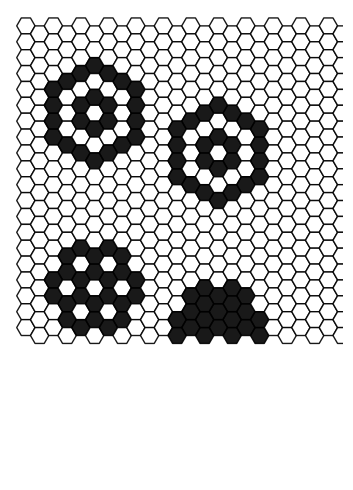

In [2]:
H, W = 20, 24

t1 = toy_hex_image('double_hex', H, W, px=5, py=5)
t2 = toy_hex_image('double_hex', H, W, px=14, py=8)
t3 = toy_hex_image('snowflake_3', H, W, px=5, py=16)
t4 = toy_hex_image('snowflake_4', H, W, px=14, py=19)

tensor = (t1 + t2 + t3 + t4).astype('float32')
plot_hextensor(tensor, figname='input');

## Hexagonal convolution

The API mirrors PyTorch HexagDLy's: `Conv2d(in_channels, out_channels, kernel_size, stride, bias, debug)`. With `debug=True` every kernel weight is set to `1`, so the output at each pixel is simply the sum over its hexagonal neighbourhood -- a direct way to see that the operation respects the 6-fold symmetry of the grid.

Input shape:  (1, 20, 24, 1)
Output shape: (1, 20, 24, 1)


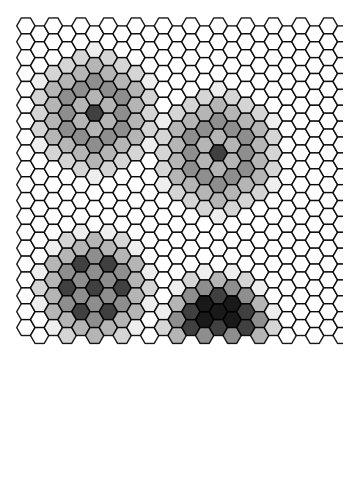

In [3]:
hex_conv = hgly.Conv2d(in_channels=1, out_channels=1, kernel_size=1, stride=1, bias=False, debug=True)

hex_conved_tensor = hex_conv(keras.ops.convert_to_tensor(tensor))
print('Input shape: ', tensor.shape)
print('Output shape:', hex_conved_tensor.shape)
plot_hextensor(hex_conved_tensor, figname='hex_conved');

Compare this to a standard *square* $3\times3$ kernel (all weights 1, same-padded) applied with `keras.ops.conv`: it destroys the symmetry, giving a different response on odd vs. even columns because of the column offset the hexagonal addressing scheme requires.

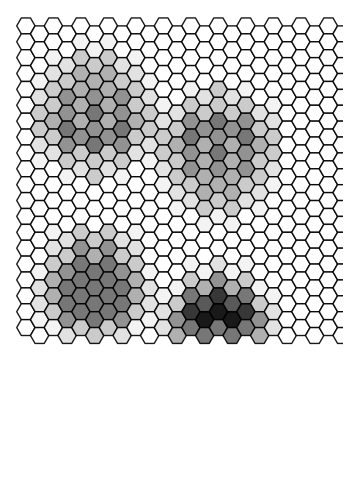

In [4]:
square_kernel = np.ones((3, 3, 1, 1), dtype='float32')
padded = keras.ops.pad(keras.ops.convert_to_tensor(tensor), [[0, 0], [1, 1], [1, 1], [0, 0]])
square_conved_tensor = keras.ops.conv(padded, square_kernel, strides=(1, 1), padding='valid', data_format='channels_last')
plot_hextensor(square_conved_tensor, figname='square_conved');

## Hexagonal max pooling

`MaxPool2d` follows the same hexagonal addressing as `Conv2d`.

Output shape: (1, 10, 12, 1)


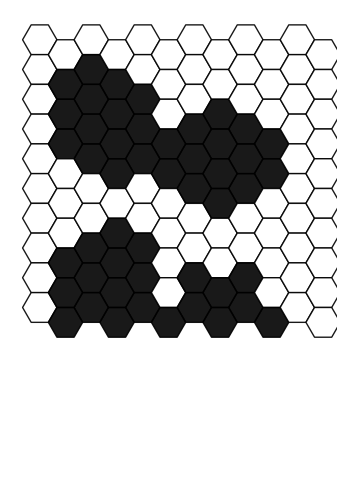

In [5]:
hex_pool = hgly.MaxPool2d(kernel_size=1, stride=2)
pooled_tensor = hex_pool(keras.ops.convert_to_tensor(tensor))
print('Output shape:', pooled_tensor.shape)
plot_hextensor(pooled_tensor, figname='hex_pooled');

## New: `share_neighbors` -- weight sharing by hexagonal ring

Upstream HexagDLy gives every cell of a hexagonal kernel its own independent weight. `share_neighbors=True` instead ties all cells of the same hex ring (ring 0 = centre, ring $r$ = the $6r$ cells at hex-distance $r$) to a single weight, exactly like the ring-tied kernels used in TDSCAN. This cuts the parameter count from $1 + 3n(n+1)$ per channel pair down to $n+1$, and enforces exact 6-fold rotational symmetry of the learned kernel (no HexagDLy equivalent).

In [6]:
n = 2
shared_conv = hgly.Conv2d(in_channels=1, out_channels=1, kernel_size=n, stride=1, bias=False, share_neighbors=True)
_ = shared_conv(keras.ops.convert_to_tensor(tensor))  # build
print('ring_weights shape (num_rings, in, out):', shared_conv.ring_weights.shape)
print('vs. a full (non-shared) kernel: ', 1 + 3 * n * (n + 1), 'independent weights per channel pair')

ring_weights shape (num_rings, in, out): (3, 1, 1)
vs. a full (non-shared) kernel:  19 independent weights per channel pair


## New: `Conv3d(depth_padding="same")` -- centred temporal convolution

HexagDLy's `Conv3d` only supports `"valid"` padding on the depth (time) axis: the output depth shrinks by `kernel_depth - 1`. `depth_padding="same"` zero-pads the depth axis instead, so the temporal kernel is centred on every time step and the output depth equals the input depth -- matching, e.g., TDSCAN's temporal window convention (`eps_t` taps each side, zero-padded borders).

In [7]:
D = 9  # depth (time) steps
video = np.stack([tensor[0]] * D)[None, ...].astype('float32')  # (1, D, H, W, 1)

conv3d_valid = hgly.Conv3d(in_channels=1, out_channels=1, kernel_size=(5, 1), stride=1, bias=False, debug=True)
conv3d_same = hgly.Conv3d(in_channels=1, out_channels=1, kernel_size=(5, 1), stride=1, bias=False, debug=True, depth_padding='same')

out_valid = conv3d_valid(keras.ops.convert_to_tensor(video))
out_same = conv3d_same(keras.ops.convert_to_tensor(video))
print('input depth:       ', video.shape[1])
print('output depth valid:', out_valid.shape[1], '(shrunk by kernel_depth - 1)')
print('output depth same: ', out_same.shape[1], '(preserved)')

input depth:        9
output depth valid: 5 (shrunk by kernel_depth - 1)
output depth same:  9 (preserved)
